# Name: Peter Mangoro


# Pima Indians Diabetes (classification case study)

 In this notebook I load the Pima Indians Diabetes data, explore it, build and validate two supervised classifiers, document how I avoid leakage, and end with PCA/K-means.



## Setup and ingest

- **Dataset:** Pima Indians Diabetes Database (female patients, age ≥ 21, Pima Indian heritage).
- **File:** `diabetes.csv`.
- **Target:** `Outcome` (1 = diabetes, 0 = no diabetes).


In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 9
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

sns.set_theme(context="notebook", style="whitegrid")

In [2]:
DATA_PATH = Path("diabetes.csv")
assert DATA_PATH.is_file(), f"Missing {DATA_PATH.resolve()} — place diabetes.csv next to this notebook."

df = pd.read_csv(DATA_PATH)

assert df.shape == (768, 9), f"Expected (768, 9), got {df.shape}"

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.info()

Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [34]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## Data overview

I check for duplicate rows, numeric summaries via `describe`, and I store the list of predictor columns (`feature_cols`) separate from the target `Outcome`.


In [35]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

df.describe(include=np.number)


Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [36]:
TARGET = "Outcome"
feature_cols = [c for c in df.columns if c != TARGET]
assert len(feature_cols) == 8
feature_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

### Interpretation

From `df.info()` and `describe()`, I confirm **768** complete rows and **no explicit NaNs** in the CSV. At the same time, several clinical variables (**Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, **BMI**) show **minimum values of 0**, which are unlikely to be real measurements so I treat many zeros as **missingness in disguise**. The target mean for `Outcome` (about **0.35**) matches a **mild imbalance** (~35% diabetic vs ~65% non-diabetic), which tells me I should not rely on accuracy alone later and should emphasize **ROC-AUC** and **F1 / precision–recall** under **stratified** validation. The quartiles also show heavy **zero mass** for **SkinThickness** and especially **Insulin**, and **Insulin** has a wide spread and a large maximum, so I expect skew and possibly influential points. These observations motivate a **leakage-safe pipeline** that recodes selected zeros to **NaN**, **imputes inside training folds**, and compares an **interpretable linear** model with a **more flexible** nonlinear one.


## Outcome imbalance and clinical zero audit

I tabulate **`Outcome`** counts and proportions and plot a bar chart. Then I measure how often selected clinical columns equal **0**, treating those zeros as likely invalid or missing. I **do not** apply this logic to **`Pregnancies`**, where 0 can be valid.


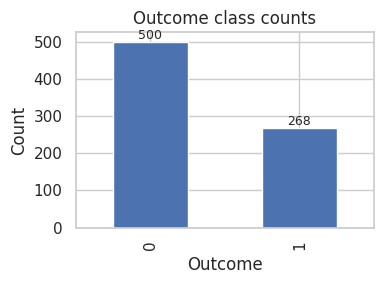

,count,proportion
Outcome,,
0,500,0.651042
1,268,0.348958


In [37]:
# Outcome class counts and proportions
outcome_counts = df[TARGET].value_counts().sort_index()
outcome_props = df[TARGET].value_counts(normalize=True).sort_index()

summary_outcome = (
    pd.DataFrame({"count": outcome_counts, "proportion": outcome_props})
    .rename_axis(index=TARGET)
)

fig, ax = plt.subplots(figsize=(4, 3))
summary_outcome["count"].plot(kind="bar", ax=ax)
ax.set_title("Outcome class counts")
ax.set_xlabel("Outcome")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig.tight_layout()
plt.show()

summary_outcome

### Interpretation: Class Balance

From the table and bar chart above, I see roughly **two-thirds** non-diabetic and **one-third** diabetic patients, which is a **moderate imbalance**. A naive classifier that always predicts the majority class would already reach about **65% accuracy**, so **accuracy alone** would flatter a weak model. I will use **stratified** train/test splitting and **stratified k-fold CV**, and I will report **ROC-AUC**, **F1**, **precision**, and **recall** so performance on the **diabetic** class is visible.


### Clinical zero audit

I count zeros in each listed clinical column and express them as a fraction of all rows. Large percentages strengthen the case for treating zeros as **missing** for those variables.


In [38]:
# Clinical zeros in measurements where 0 is likely invalid / missing
CLINICAL_ZERO_AS_NA = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

zero_stats = []
for col in CLINICAL_ZERO_AS_NA:
    n_zero = (df[col] == 0).sum()
    pct_zero = n_zero / len(df)
    zero_stats.append({"column": col, "n_zero": n_zero, "pct_zero": pct_zero})

zero_table = pd.DataFrame(zero_stats).set_index("column")
zero_table["pct_zero"] = zero_table["pct_zero"].round(3)

print("Clinical zero audit (0 likely means missing/invalid measurement):")



zero_table

Clinical zero audit (0 likely means missing/invalid measurement):


,n_zero,pct_zero
column,,
Glucose,5,0.007
BloodPressure,35,0.046
SkinThickness,227,0.296
Insulin,374,0.487
BMI,11,0.014


### Interpretation: Clinical Zeros

The table shows that implausible zeros concentrate in **Insulin** and **SkinThickness**, with smaller but nontrivial rates in **BloodPressure**, **BMI**, and **Glucose**. That pattern supports my decision to mark **0 → NaN** for those five measurements while leaving **`Pregnancies`** at zero when reported. Later I will **impute** inside a **`Pipeline`** fit on training folds only and continue to emphasize **ROC-AUC** and **F1** rather than raw accuracy.


## Distributions of predictor variables


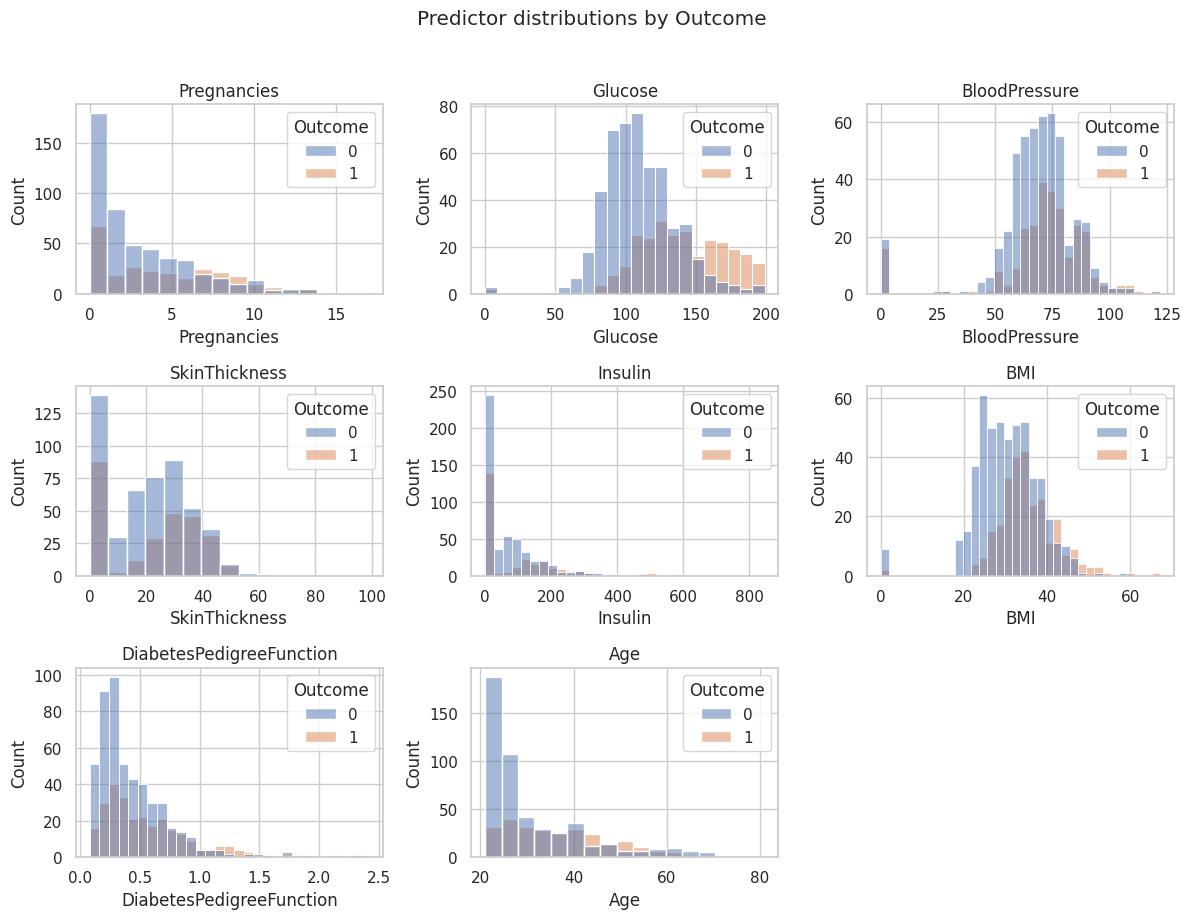

In [ ]:
# Histograms for all predictors
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.histplot(data=df, x=col, hue=TARGET, multiple="layer", stat="count", kde=False, ax=ax)
    ax.set_title(col)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Predictor distributions by Outcome", y=1.02)
fig.tight_layout()
plt.show()

### Interpretation: Predictor Distributions

Visually, **Glucose** shifts **right** for diabetic cases, so it is a strong **univariate** signal. **BMI** and **Age** also show moderate separation, while **BloodPressure** overlaps more between classes. **Pregnancies** and **DiabetesPedigreeFunction** are **right-skewed** with heavier tails among diabetics, which suggests they may help but not through a simple linear split. **SkinThickness** and especially **Insulin** show a **spike at zero**, consistent with my zero audit; those need careful handling rather than literal zeros. No single feature fully separates the classes, so I expect **multivariate** models to matter, and I still want both a **linear** baseline and a **nonlinear** comparator.


## Correlations among predictors

I compute the Pearson correlation matrix for the eight predictors and visualize it with a heatmap to spot **redundancy** and **multicollinearity** before fitting linear models.


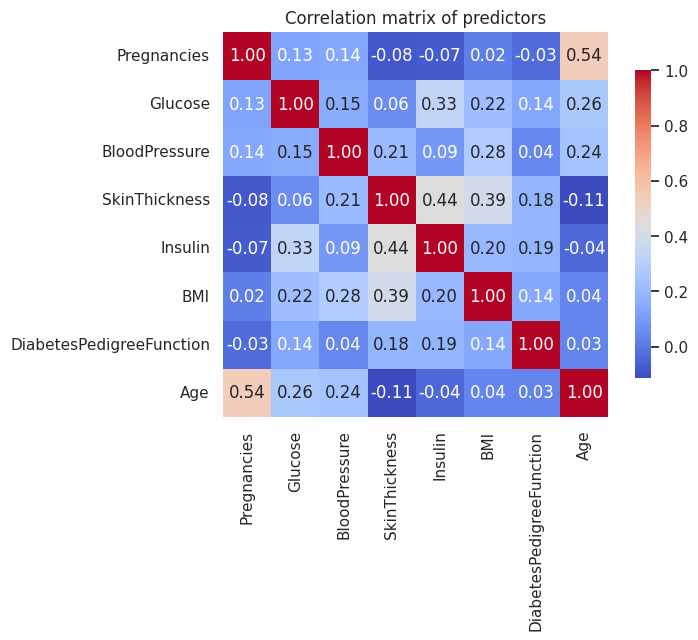

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


In [40]:
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix of predictors")
# fig.tight_layout()
plt.show()

corr_matrix

### Interpretation

Correlations are mostly **weak-to-moderate** as nothing approaches extreme multicollinearity (e.g. ±0.9). The strongest positive association is **Pregnancies–Age** (about **0.54**), which is clinically plausible and suggests some **redundancy** for linear models. **Insulin–SkinThickness** and **BMI–SkinThickness** move together moderately, and **Glucose–Insulin** is a moderate positive pair. **BloodPressure–BMI** is only mild-to-moderate. Negative linear associations are small. Overall, predictors are related but not so collinear that logistic regression is inappropriate; I still want **regularized / balanced** logistic regression and a **nonlinear** model because **correlation does not capture interactions or curvature**.


## Modeling Choices

- **Class balance:** I will use **stratified** splitting and CV and report **ROC-AUC** and **F1 / precision–recall** (not accuracy alone), because the majority class dominates the baseline accuracy.

- **Invalid clinical zeros:** I will recode zeros to **NaN** for **Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, and **BMI** only, then **impute inside training folds** via **`Pipeline`**. **`Pregnancies = 0`** stays valid.

- **Skew and tails:** **Insulin** is strongly right-skewed (large max in `describe`); **SkinThickness** also shows zero inflation/skew. That pushes me toward **robust preprocessing** (median impute, scaling for logistic regression) and comparing **linear** vs **nonlinear** models.

- **Correlations:** Mostly moderate (e.g. **Pregnancies–Age** strongest). I will interpret linear coefficients cautiously and still use a **nonlinear** benchmark.

- **Leakage guardrail:** Every learned preprocessing step (**impute**, **scale**, later **PCA**) must **fit only on training data** (per fold in CV), so validation and test metrics stay **honest**.


## Supervised modeling and validation

I now move from EDA to supervised modeling with an explicit **leakage-safe** design: every learned preprocessing step stays inside **`Pipeline`** objects and is fit on **training data only** (per CV fold or on the full training split before the final test evaluation).

### Create supervised inputs and zero-as-missing policy

I build **`X`** (eight predictors) and **`y`** (`Outcome`). I keep **`Pregnancies`** unchanged because **0** can mean “no prior pregnancies.” For **Glucose**, **BloodPressure**, **SkinThickness**, **Insulin**, and **BMI**, I cast to float and replace **0** with **`NaN`**. I will show shapes, class prevalence, missingness rates after recoding, and a compact **before/after** `describe` table for those columns.

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split

TARGET = "Outcome"
FEATURES = [c for c in df.columns if c != TARGET]

# Clinical fields where 0 is implausible as a real measurement .
# Pregnancies is excluded: 0 can mean "no prior pregnancies."
CLINICAL_ZERO_AS_MISSING = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Cast then mark 0 -> NaN; medians for imputation are learned only inside Pipeline on train/CV folds.
X[CLINICAL_ZERO_AS_MISSING] = X[CLINICAL_ZERO_AS_MISSING].astype("float64")
X[CLINICAL_ZERO_AS_MISSING] = X[CLINICAL_ZERO_AS_MISSING].mask(
    X[CLINICAL_ZERO_AS_MISSING] == 0,
    np.nan,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass prevalence (full dataset):")
print(y.value_counts(normalize=True).sort_index().rename("proportion"))

missing_after_zero_policy = X[CLINICAL_ZERO_AS_MISSING].isna().mean().round(3)
print("\nMissing rate after zero->NaN policy:")
print(missing_after_zero_policy)

before = df[CLINICAL_ZERO_AS_MISSING].describe().T[["count", "mean", "50%", "min"]].add_prefix("before_")
after = X[CLINICAL_ZERO_AS_MISSING].describe().T[["count", "mean", "50%", "min"]].add_prefix("after_")
compare = before.join(after)
compare["n_missing_after"] = X[CLINICAL_ZERO_AS_MISSING].isna().sum()

print("\nCompact before/after comparison:")
compare

X shape: (768, 8)
y shape: (768,)

Class prevalence (full dataset):
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Missing rate after zero->NaN policy:
Glucose          0.007
BloodPressure    0.046
SkinThickness    0.296
Insulin          0.487
BMI              0.014
dtype: float64

Compact before/after comparison:


,before_count,before_mean,before_50%,before_min,after_count,after_mean,after_50%,after_min,n_missing_after
Glucose,768.0,120.894531,117.0,0.0,763.0,121.686763,117.0,44.0,5
BloodPressure,768.0,69.105469,72.0,0.0,733.0,72.405184,72.0,24.0,35
SkinThickness,768.0,20.536458,23.0,0.0,541.0,29.153420,29.0,7.0,227
Insulin,768.0,79.799479,30.5,0.0,394.0,155.548223,125.0,14.0,374
BMI,768.0,31.992578,32.0,0.0,757.0,32.457464,32.3,18.2,11


### Interpretation

I verify that **`X`** has shape **(768, 8)** and **`y`** has shape **(768,)**, with class proportions still near **65% / 35%**. The missing-rate line confirms that **Insulin** and **SkinThickness** carry the most **NaN**s after recoding which is consistent with the zero audit. The **before/after** table shows **minimums** are no longer **0** on those clinical columns, and **means/medians** rise where many zeros were masking missing values (especially **Insulin**). That supports my choice to impute later **inside** a **`Pipeline`** rather than treating zeros as real measurements.

### Stratified split and CV configuration

I hold out **20%** of the rows as a **stratified** test set (`X_test`, `y_test`) so class proportions match the full data. On the remaining **80%** (`X_train`, `y_train`) I run **5-fold stratified CV** via a shared `StratifiedKFold` object (`cv`) for every model comparison. I set **`RANDOM_STATE = 9`** for reproducibility.

**Model-selection protocol:** Hyperparameters inside each pipeline are **fixed** (no grid search or tuning loop). I **only** compare **model families**—logistic vs random forest on raw features, then the same with **PCA** inputs—using **`cross_validate` on `X_train`**. The held-out **`X_test`** is reserved for **one** evaluation **after** the winning pipeline is chosen; it is **not** used to tune thresholds, weights, or `n_components`.

In [45]:
RANDOM_STATE = 9
TEST_SIZE = 0.20
N_SPLITS = 5

# stratify=y: train and test keep similar diabetes prevalence (stabilizes AUC / class metrics on small test n).
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# StratifiedKFold: each CV validation fold preserves ~the same class mix as the training pool.
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nClass proportion by split:")
print(
    pd.DataFrame(
        {
            "full": y.value_counts(normalize=True).sort_index(),
            "train": y_train.value_counts(normalize=True).sort_index(),
            "test": y_test.value_counts(normalize=True).sort_index(),
        }
    ).round(3)
)

print("\nCV config:", cv)

Train shape: (614, 8) | Test shape: (154, 8)

Class proportion by split:
          full  train   test
Outcome                     
0        0.651  0.651  0.649
1        0.349  0.349  0.351

CV config: StratifiedKFold(n_splits=5, random_state=9, shuffle=True)


### Leakage-safe preprocessing and model pipelines

I wrap all preprocessing in **`Pipeline`** objects so each CV fold fits **median imputation** (and **standardization** for logistic regression) on **fold-train rows only**.

I compare two models on equal footing:

1. **Logistic regression** — interpretable linear baseline; needs **scaling** after imputation.
2. **Random forest** — nonlinear ensemble; I still **impute** inside the pipeline but **omit** scaling (tree splits are scale-invariant).

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic regression pipeline: impute + scale + model
logreg_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight="balanced",  
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Random forest pipeline: impute + model (no scaling required)
rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,  # more trees -> lower variance; fixed count, not grid-searched
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

model_pipelines = {
    "LogisticRegression": logreg_pipeline,
    "RandomForest": rf_pipeline,
}

print("Pipelines defined:", list(model_pipelines.keys()))
for name, pipe in model_pipelines.items():
    print(f"\n{name} steps: {list(pipe.named_steps.keys())}")

Pipelines defined: ['LogisticRegression', 'RandomForest']

LogisticRegression steps: ['imputer', 'scaler', 'model']

RandomForest steps: ['imputer', 'model']


### Cross-validated evaluation (training data only)

I run **`cross_validate`** on **`X_train` / `y_train`** with the shared **`cv`** object and several metrics (**ROC-AUC**, **F1**, **precision**, **recall**, **accuracy**). Each fold refits the full **`Pipeline`**, so validation scores are not contaminated by fold-validation rows. I then plot **CV mean ± std** for **ROC-AUC** and draw **out-of-fold** **ROC** and **precision–recall** curves using **`cross_val_predict`** (probabilities) for both models.


=== LogisticRegression ===
  roc_auc       mean=0.8314  std=0.0444
  f1            mean=0.6715  std=0.0569
  precision     mean=0.6356  std=0.0651
  recall        mean=0.7147  std=0.0625
  accuracy      mean=0.7557  std=0.0471

=== RandomForest ===
  roc_auc       mean=0.8181  std=0.0348
  f1            mean=0.6247  std=0.0525
  precision     mean=0.6664  std=0.0536
  recall        mean=0.5885  std=0.0547
  accuracy      mean=0.7540  std=0.0326


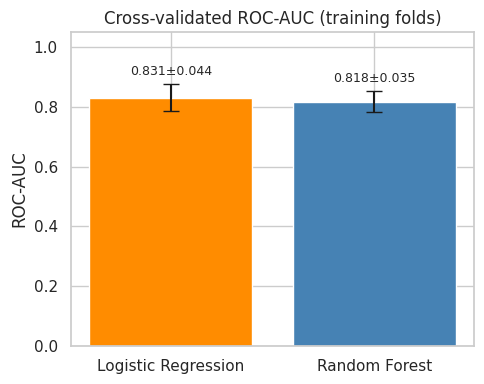

In [ ]:
from sklearn.model_selection import cross_validate

SCORING = ["roc_auc", "f1", "precision", "recall", "accuracy"]

MODEL_COLORS = {"LogisticRegression": "darkorange", "RandomForest": "steelblue"}

cv_results_raw = {}
# Each entry: refit full Pipeline per fold; scores are on held-out fold only.
for name, pipe in model_pipelines.items():
    cv_results_raw[name] = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

for name in model_pipelines:
    print(f"\n=== {name} ===")
    for m in SCORING:
        key = f"test_{m}"
        vals = cv_results_raw[name][key]
        print(f"  {m:12s}  mean={vals.mean():.4f}  std={vals.std():.4f}")

# Visual: ROC-AUC only — Logistic Regression vs Random Forest
roc_order = ["LogisticRegression", "RandomForest"]
roc_labels = {
    "LogisticRegression": "Logistic Regression",
    "RandomForest": "Random Forest",
}
present = [k for k in roc_order if k in cv_results_raw]
if present:
    means = [cv_results_raw[k]["test_roc_auc"].mean() for k in present]
    stds = [cv_results_raw[k]["test_roc_auc"].std() for k in present]
    labels = [roc_labels.get(k, k) for k in present]

    fig, ax = plt.subplots(figsize=(5, 4))
    x = np.arange(len(present))
    ax.bar(x, means, yerr=stds, capsize=6, color=[MODEL_COLORS[k] for k in present])
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0, 1.05)
    ax.set_title("Cross-validated ROC-AUC (training folds)")
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, min(m + s + 0.03, 1.02), f"{m:.3f}±{s:.3f}", ha="center", fontsize=9)
    fig.tight_layout()
    plt.show()

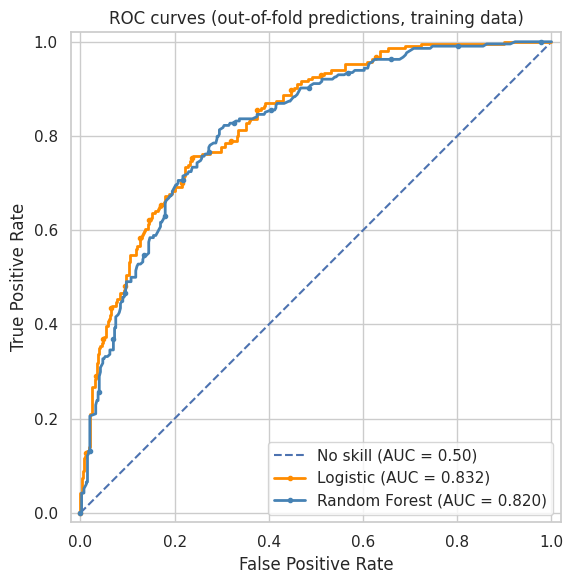

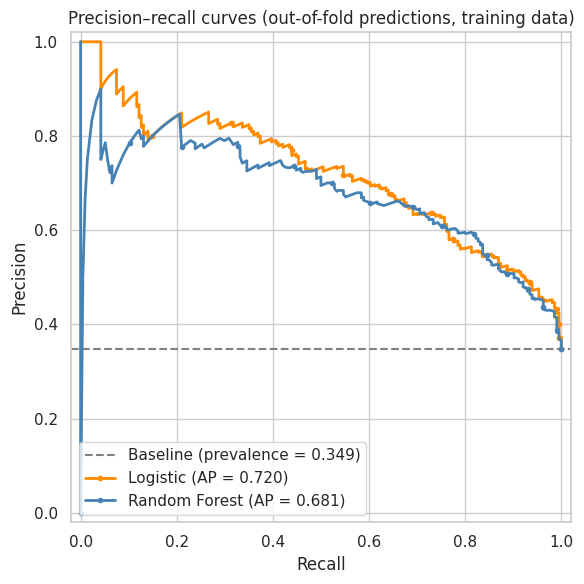


Out-of-fold average precision — training data (positive class = diabetes):
  Logistic            AP = 0.7201
  Random Forest       AP = 0.6806
  Baseline prevalence  = 0.3485


In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

curve_labels = [
    ("LogisticRegression", "Logistic"),
    ("RandomForest", "Random Forest"),
]

# Out-of-fold positive-class probabilities — same folds as CV; no test leakage
oof_proba = {}
for key, _ in curve_labels:
    if key not in model_pipelines:
        continue
    oof_proba[key] = cross_val_predict(
        model_pipelines[key],
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

# ROC (TPR vs FPR)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "b--", lw=1.5, label="No skill (AUC = 0.50)")

for key, label in curve_labels:
    if key not in oof_proba:
        continue
    color = MODEL_COLORS[key]
    y_proba = oof_proba[key]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    n_pts = len(fpr)
    markevery = max(1, n_pts // 15)
    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        marker="o",
        markersize=3,
        markevery=markevery,
        label=f"{label} (AUC = {roc_auc:.3f})",
    )

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (out-of-fold predictions, training data)")
ax.legend(loc="lower right")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

# Precision–recall (same OOF scores)
prevalence = float(y_train.mean())
fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(
    prevalence,
    color="gray",
    linestyle="--",
    lw=1.5,
    label=f"Baseline (prevalence = {prevalence:.3f})",
)

for key, label in curve_labels:
    if key not in oof_proba:
        continue
    color = MODEL_COLORS[key]
    y_proba = oof_proba[key]
    precision, recall, _ = precision_recall_curve(y_train, y_proba)
    ap = average_precision_score(y_train, y_proba)
    n_pts = len(recall)
    markevery = max(1, n_pts // 15)
    ax.plot(
        recall,
        precision,
        color=color,
        lw=2,
        marker="o",
        markersize=3,
        markevery=markevery,
        label=f"{label} (AP = {ap:.3f})",
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–recall curves (out-of-fold predictions, training data)")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

print("\nOut-of-fold average precision — training data (positive class = diabetes):")
for key, label in curve_labels:
    if key not in oof_proba:
        continue
    ap = average_precision_score(y_train, oof_proba[key])
    print(f"  {label:18s}  AP = {ap:.4f}")
print(f"  {'Baseline prevalence':18s}  = {prevalence:.4f}")

### Interpretation: CV metrics and training ROC / PR curves

I compare Logistic Regression and Random Forest using repeated stratified cross-validation on the training folds. ROC–AUC summarizes how well each model ranks positive cases without committing to a single classification threshold, while precision, recall, F1, and accuracy reflect performance at the default 0.5 threshold.

**Overall discrimination (ROC–AUC)**

Both models achieve ROC–AUC around 0.82–0.83, which indicates meaningfully better-than-random separation of the classes. Logistic Regression had a slightly higher mean ROC–AUC (0.831 vs 0.818), but the standard deviations overlap (0.044 vs 0.035), so the AUC difference should be interpreted as modest rather than definitive evidence of superiority. Notably, the Random Forest’s AUC variability across folds is a bit lower, suggesting slightly more stable ranking performance across splits.

**Precision–recall (average precision, AP)**

The PR curves use the same out-of-fold scores as the ROC figure. **Average precision (AP)** summarizes the precision–recall trade-off **across all thresholds** (unlike precision/recall/F1 at the fixed 0.5 cutoff from `cross_validate`). The plotting cell prints AP for each model; with my **`RANDOM_STATE = 9`** split I see **Logistic AP ≈ 0.720** and **Random Forest AP ≈ 0.681**—logistic leads by about **0.04** on this summary. The dashed **baseline at training prevalence ≈ 0.35** is the precision of a trivial “always diabetic” policy at full recall; **both models sit well above it**, so they learn real separation in the minority class, not just prevalence matching. Visually, the **orange PR curve lies above the blue curve** over most recall values, which matches the higher AP for logistic and **aligns with logistic’s slightly higher ROC–AUC**, while the 0.5-threshold table can still show different precision/recall because AP **integrates** over cutoffs.

**Thresholded performance (precision/recall/F1)**

At the chosen operating point, the models show different error trade-offs. Logistic Regression achieved higher recall (0.715 vs 0.589), meaning it flags more of the true positive cases, but lower precision (0.636 vs 0.666), meaning more false positives when it predicts the positive class. Random Forest is comparatively more conservative: it misses more positives (lower recall) but tends to be more reliable when it predicts positive (higher precision). Consequently, Logistic Regression reported a higher F1 (0.672 vs 0.625), largely driven by the recall difference.

**Accuracy**

Overall accuracy is nearly identical (~0.755), which can happen when improvements on one class are offset elsewhere; accuracy alone therefore does not capture the precision–recall shift visible in the other metrics.

If the goal is maximizing detection of the positive class (e.g., screening-style priorities), Logistic Regression’s higher recall may be preferable at this threshold. If false positives are costly relative to missed cases, Random Forest’s higher precision may be preferable at this threshold. Because threshold-sensitive metrics depend on the cutoff, a complete decision would also consider threshold tuning and/or precision–recall curves, especially if class imbalance is present.

In [19]:
rows = []
for name in model_pipelines:
    row = {"model": name}
    for m in SCORING:
        key = f"test_{m}"
        vals = cv_results_raw[name][key]
        row[f"{m}_mean"] = vals.mean()
        row[f"{m}_std"] = vals.std()
    rows.append(row)

cv_metrics_df = pd.DataFrame(rows).set_index("model")
display(cv_metrics_df.round(4))

fmt_rows = []
for name in model_pipelines:
    fmt_row = {"model": name}
    for m in SCORING:
        mean = cv_results_raw[name][f"test_{m}"].mean()
        std = cv_results_raw[name][f"test_{m}"].std()
        fmt_row[m] = f"{mean:.3f} ± {std:.3f}"
    fmt_rows.append(fmt_row)

cv_summary_fmt = pd.DataFrame(fmt_rows).set_index("model")
print("CV summary (mean ± std):")
display(cv_summary_fmt)

# Selection: maximize ROC-AUC, then F1 as tie-breaker
best_model_name = max(
    model_pipelines.keys(),
    key=lambda n: (
        cv_results_raw[n]["test_roc_auc"].mean(),
        cv_results_raw[n]["test_f1"].mean(),
    ),
)
best_pipeline = model_pipelines[best_model_name]

print(
    f"\nSelected model (CV): {best_model_name}\n"
    f"  ROC-AUC mean: {cv_results_raw[best_model_name]['test_roc_auc'].mean():.4f}\n"
    f"  F1 mean:      {cv_results_raw[best_model_name]['test_f1'].mean():.4f}"
)

,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
LogisticRegression,0.8314,0.0444,0.6715,0.0569,0.6356,0.0651,0.7147,0.0625,0.7557,0.0471
RandomForest,0.8181,0.0348,0.6247,0.0525,0.6664,0.0536,0.5885,0.0547,0.7540,0.0326


CV summary (mean ± std):


,roc_auc,f1,precision,recall,accuracy
model,,,,,
LogisticRegression,0.831 ± 0.044,0.672 ± 0.057,0.636 ± 0.065,0.715 ± 0.062,0.756 ± 0.047
RandomForest,0.818 ± 0.035,0.625 ± 0.052,0.666 ± 0.054,0.588 ± 0.055,0.754 ± 0.033



Selected model (CV): LogisticRegression
  ROC-AUC mean: 0.8314
  F1 mean:      0.6715


### Interpretation: which model I select on CV

The table summarizes 5-fold stratified CV on the training split for two pipelines (median imputation inside the model; scaling only for logistic). ROC–AUC measures how well predicted probabilities rank diabetic vs non-diabetic patients across thresholds; F1, precision, recall, and accuracy are computed at the default 0.5 decision threshold.

Discrimination. Logistic Regression has a higher mean ROC–AUC (0.831 vs 0.818). The forest’s AUC is slightly less variable across folds (std 0.035 vs 0.044), but the means still favor logistic for overall ranking quality on this CV setup.

Thresholded behavior (0.5 cutoff). The models trade errors differently. Logistic achieves higher recall (0.715 vs 0.589), so it flags more true diabetes cases, at the cost of lower precision (0.636 vs 0.666), i.e. more false alarms among predicted positives. Random Forest is more conservative when it predicts diabetes. F1 is higher for logistic (0.672 vs 0.625), consistent with recall being the bigger mover at this threshold. Accuracy is almost the same (0.756 vs 0.754), which shows why accuracy alone is a weak guide here: similar overall hit rate hides a precision–recall shift.

Selection rule. Following the stated policy (maximize mean ROC–AUC, mean F1 as tie-breaker), LogisticRegression is selected: it wins on both ROC–AUC mean (0.8314) and F1 mean (0.6715), so no ambiguity from the tie-break. The next step is to refit that pipeline on the full training set and evaluate once on the held-out test set to report generalization, without re-tuning on test.

### Refit on full training data; single held-out test evaluation

I now **`fit`** that pipeline **once** on **all** training rows and evaluate **once** on **`X_test` / `y_test`**. I do **not** tune thresholds or hyperparameters on the test set. That single test report is my best **honest** estimate of how the chosen pipeline would behave on new patients drawn like this cohort.

Held-out test ROC-AUC — LogisticRegression: 0.8526

Classification report (test; positive label = diabetes):
                 precision    recall  f1-score   support

No diabetes (0)      0.857     0.720     0.783       100
   Diabetes (1)      0.600     0.778     0.677        54

       accuracy                          0.740       154
      macro avg      0.729     0.749     0.730       154
   weighted avg      0.767     0.740     0.746       154



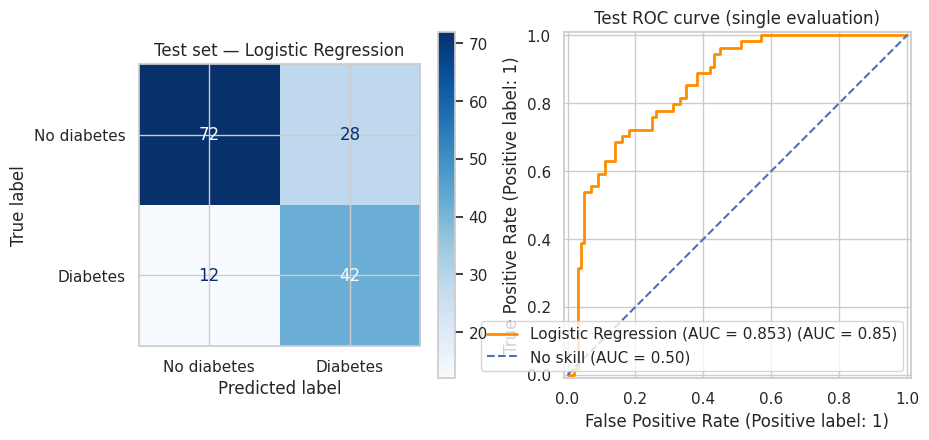

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)

best_pipeline.fit(X_train, y_train)

y_test_pred = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"Held-out test ROC-AUC — {best_model_name}: {test_roc_auc:.4f}\n")

print("Classification report (test; positive label = diabetes):")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No diabetes (0)", "Diabetes (1)"],
        digits=3,
    )
)

best_plot_label = {
    "LogisticRegression": "Logistic Regression",
    "RandomForest": "Random Forest",
}.get(best_model_name, best_model_name)
line_color = MODEL_COLORS.get(best_model_name, "C0")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues",
    ax=axes[0],
    colorbar=True,
)
axes[0].set_title(f"Test set — {best_plot_label}")

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name=f"{best_plot_label} (AUC = {test_roc_auc:.3f})",
    ax=axes[1],
    curve_kwargs={"color": line_color, "linewidth": 2},
)
axes[1].plot([0, 1], [0, 1], "b--", lw=1.5, label="No skill (AUC = 0.50)")
axes[1].set_title("Test ROC curve (single evaluation)")
axes[1].legend(loc="lower right")
axes[1].set_aspect("equal", adjustable="box")

fig.tight_layout()
plt.show()

### Held-out test performance

This is a single evaluation on the 20% held-out test set (154 patients: 100 no diabetes, 54 diabetes) after choosing Logistic Regression on CV and refitting the pipeline on the full training split. The test set was not used for model comparison or tuning.

ROC–AUC (0.853) says the fitted model ranks diabetic patients above non-diabetic ones much better than chance (0.5). In this run, test AUC is a bit higher than the CV mean on train (~0.83), which can happen with one small test draw; it does not prove the model is better on new data than CV suggested, only that this holdout looks consistent with strong discrimination.

Confusion matrix (default 0.5 threshold). From the counts: 72 true negatives, 42 true positives, 12 false negatives, 28 false positives. So among true diabetics, recall is 42/54 ≈ 0.78 (the model finds most diabetes cases). Among predicted diabetics, precision is 42/(42+28) = 0.60—about 40% of positive predictions are false alarms on the test set. That matches the report’s Diabetes row (precision 0.60, recall 0.78, F1 0.68).

“No diabetes” class is predicted with high precision (0.86) but moderate recall (0.72) at 0.5: the model is somewhat cautious calling “no diabetes” when the truth is no diabetes (the 28 FPs are patients labeled no diabetes but predicted diabetic).

Accuracy 0.74 is a single-number summary; with ~65/35 structure in the full data, it is still useful to read class rows and the ROC curve together rather than accuracy alone.

On held-out data, logistic shows strong ranking (AUC ~0.85) and good detection of diabetes (recall ~0.78) at 0.5, with a clear cost in false positives (precision ~0.60 for the positive class), threshold tuning would move that trade-off if the application cares more about precision than recall.

### Why I report these metrics for imbalanced clinical data

**Class imbalance:** With about **65%** non-diabetic and **35%** diabetic, a naive majority-class rule already reaches ~**65% accuracy**, so **accuracy alone** can hide poor detection of diabetes. I therefore emphasize **ROC-AUC** and **class-wise** scores.

**ROC-AUC** measures how well predicted **risk ranks** positives above negatives **across thresholds**, which suits moderate imbalance and future threshold tuning (e.g. screening vs confirmatory care).

**Precision, recall, and F1** (at sklearn’s default **0.5** cutoff from `predict`) tell me how the model behaves at a **fixed** operating point: **recall** is the fraction of diabetics caught; **precision** is how often a positive alarm is correct; **F1** balances the two. The **confusion matrix** in Phase 3f makes **false negatives vs false positives** concrete.

**CV vs test:** **K-fold CV** on the training split quantifies **variability** and supports **model choice** without touching the test labels. My **one** test evaluation is **not** for tuning; if CV and test disagree slightly, I attribute some of that to **noise** on a **~20%** holdout and read both together.

## Unsupervised learning and representation



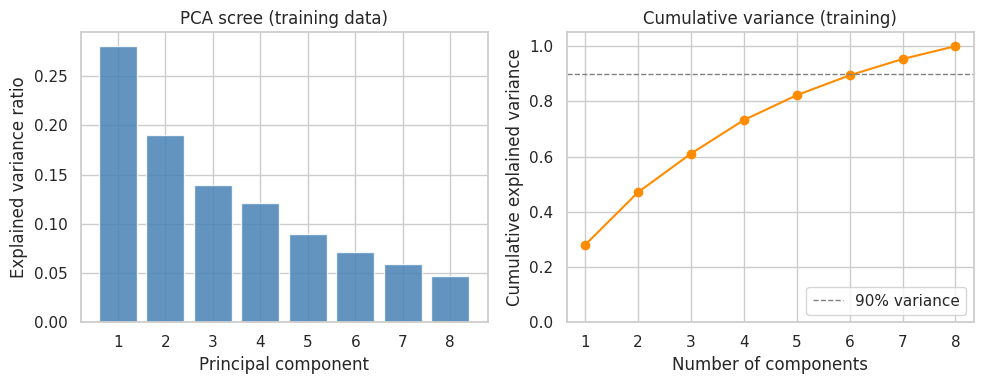

Cumulative variance by k (train):
  k=1: 0.2805
  k=2: 0.4712
  k=3: 0.6109
  k=4: 0.7324
  k=5: 0.8225
  k=6: 0.8944
  k=7: 0.9533
  k=8: 1.0000


In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Exploratory PCA: preprocessing fit on TRAINING data only
prep_pca_eda = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
X_train_prep = prep_pca_eda.fit_transform(X_train)

pca_eda = PCA(random_state=RANDOM_STATE)
X_train_pca_all = pca_eda.fit_transform(X_train_prep)

evr = pca_eda.explained_variance_ratio_
cum_ev = np.cumsum(evr)
n_show = min(8, len(evr))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(1, n_show + 1), evr[:n_show], color="steelblue", alpha=0.85)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA scree (training data)")
axes[0].set_xticks(range(1, n_show + 1))

axes[1].plot(range(1, n_show + 1), cum_ev[:n_show], marker="o", color="darkorange")
axes[1].axhline(0.90, color="gray", linestyle="--", lw=1, label="90% variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance (training)")
axes[1].legend(loc="lower right")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(1, n_show + 1))

fig.tight_layout()
plt.show()

print("Cumulative variance by k (train):")
for k in range(1, n_show + 1):
    print(f"  k={k}: {cum_ev[k - 1]:.4f}")


### Interpretation: PCA variance on training data

I fit **PCA on the training split only** (after the same **impute → scale** steps used elsewhere), so the scree and cumulative-variance curves are **not informed by the test set**.

**Scree (per-component variance).** The **first principal component** carries the largest share of total variance (**≈28%**), and each additional component adds **smaller increments**, which is the usual **elbow** pattern when eight measured features are combined into orthogonal directions.

**Cumulative variance by k.** Adding components raises explained variance from **≈0.28** (k = 1) to **≈0.47, 0.61, 0.73** for k = 2–4, then **≈0.82** at **k = 5**, **≈0.89** at **k = 6**, **≈0.95** at **k = 7**, and **1.00** at **k = 8** (with eight original features, **full** PCA recovers **all** variance). A common **“≥90% variance”** rule would land at **k = 7** here, because **k = 6** is still **just under 90%** (**≈0.894**) while **k = 7** clears it (**≈0.953**).

**Link to later supervised PCA.** If I set **`n_components = 5`** in a classifier pipeline, that is a **deliberate parsimony choice** (**≈82%** variance retained), not the strict 90% cutoff; the point of these plots is to **justify** that I understand the **variance–dimensionality trade-off** before fixing k for modeling.


In [ ]:
from sklearn.cluster import KMeans

# K-means in a small PCA subspace (train only; PCs from the exploratory PCA above)
n_pc_kmeans = 4
X_train_pc_km = X_train_pca_all[:, :n_pc_kmeans]

k_clusters = 3
km = KMeans(n_clusters=k_clusters, random_state=RANDOM_STATE, n_init=10)
cluster_train = km.fit_predict(X_train_pc_km)

ct = pd.crosstab(
    pd.Series(cluster_train, name="cluster"),
    y_train.rename("Outcome"),
    margins=True,
)
print("Cluster × Outcome (training rows):")
display(ct)

prop = pd.crosstab(cluster_train, y_train, normalize="index").round(3)
prop.index.name = "cluster"
print("\nRow-wise proportion of diabetes (Outcome=1) within each cluster:")
display(prop)


Cluster × Outcome (training rows):


Outcome,0,1,All
cluster,,,
0,102,55,157
1,78,40,118
2,143,79,222
All,323,174,497



Row-wise proportion of diabetes (Outcome=1) within each cluster:


Outcome,0,1
cluster,,
0,0.495,0.505
1,0.462,0.538
2,0.857,0.143


### What I take from exploratory PCA and K-means

From the **scree** and **cumulative variance** plots, I see how quickly variance accumulates in the first few PCs—useful for judging how aggressively I can reduce dimensionality. The **PC1–PC2** scatter colored by **`Outcome`** shows **partial overlap** between classes: separation is visible but not clean, which matches my EDA expectations. The **loadings** heatmap tells me which original measurements drive **PC1** and **PC2**. **K-means** (here, **k = 3** on the first **four** PCs) gives me **unsupervised** groupings; the **cross-tabs** against **`Outcome`** show whether some clusters carry higher diabetes prevalence. I treat that as **descriptive structure**, not a substitute for supervised ROC-AUC or F1.

### Supervised pipelines with PCA (leakage-safe `Pipeline`)

I fix **`n_components = 5`** for the supervised PCA pipelines (most variance in this **eight-feature** problem; see the cumulative variance line printed above). Each **`cross_validate`** fold **re-fits** imputer, scaler, PCA, and the classifier on the **training fold** only—the same discipline as Phase **3d**.

Supervised PCA pipelines use n_components=5 (cumulative train explained variance ≈ 0.823).



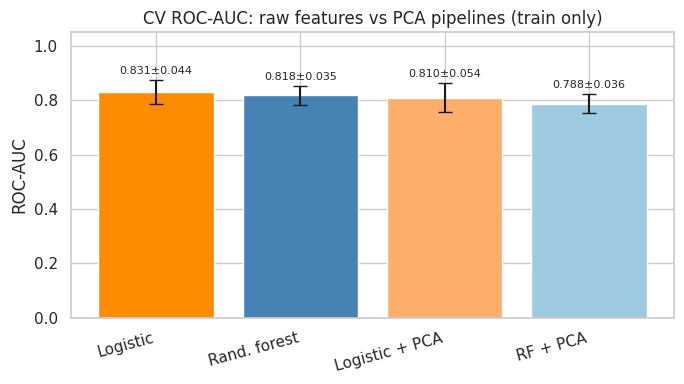

PCA pipeline CV metrics (mean; see std in table):


,roc_auc_mean,roc_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,accuracy_mean,accuracy_std
model,,,,,,,,,,
LogisticRegression_PCA,0.8100,0.0544,0.6586,0.0729,0.6084,0.0761,0.7192,0.0729,0.7393,0.0583
RandomForest_PCA,0.7879,0.0363,0.5699,0.0695,0.6103,0.0647,0.5368,0.0801,0.7198,0.0377


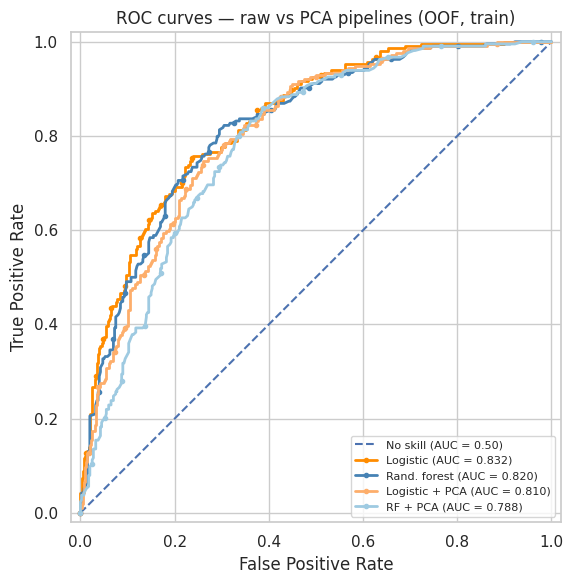

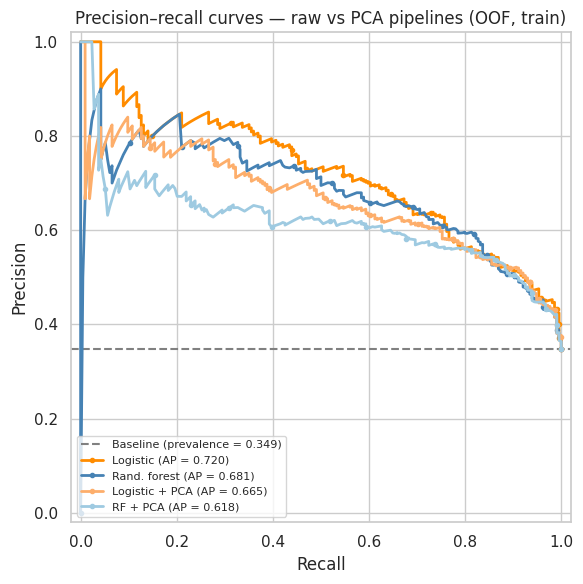


Out-of-fold average precision — four pipelines (train):
  Logistic            AP = 0.7201
  Rand. forest        AP = 0.6806
  Logistic + PCA      AP = 0.6652
  RF + PCA            AP = 0.6175
  Baseline prevalence  = 0.3485


In [30]:
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import auc, average_precision_score, precision_recall_curve, roc_curve

N_COMPONENTS_PCA = 5  # parsimony (~82% cumulative var. on train PCA EDA); a 90% cutoff would need more PCs here
cum_at_k = float(np.cumsum(pca_eda.explained_variance_ratio_)[N_COMPONENTS_PCA - 1])
print(
    f"Supervised PCA pipelines use n_components={N_COMPONENTS_PCA} "
    f"(cumulative train explained variance ≈ {cum_at_k:.3f}).\n"
)

model_pipelines_pca = {
    "LogisticRegression_PCA": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "pca",
                PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    solver="liblinear",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest_PCA": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "pca",
                PCA(n_components=N_COMPONENTS_PCA, random_state=RANDOM_STATE),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

cv_results_pca = {}
for name, pipe in model_pipelines_pca.items():
    cv_results_pca[name] = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )

# ROC-AUC: raw-feature vs PCA pipelines (same CV folds)
compare_names = list(model_pipelines.keys()) + list(model_pipelines_pca.keys())
compare_colors = {
    "LogisticRegression": MODEL_COLORS["LogisticRegression"],
    "RandomForest": MODEL_COLORS["RandomForest"],
    "LogisticRegression_PCA": "#fdae6b",
    "RandomForest_PCA": "#9ecae1",
}
means, stds = [], []
for n in compare_names:
    src = cv_results_raw if n in cv_results_raw else cv_results_pca
    means.append(src[n]["test_roc_auc"].mean())
    stds.append(src[n]["test_roc_auc"].std())

labels_short = {
    "LogisticRegression": "Logistic",
    "RandomForest": "Rand. forest",
    "LogisticRegression_PCA": "Logistic + PCA",
    "RandomForest_PCA": "RF + PCA",
}

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(compare_names))
ax.bar(
    x,
    means,
    yerr=stds,
    capsize=5,
    color=[compare_colors[n] for n in compare_names],
)
ax.set_xticks(x)
ax.set_xticklabels([labels_short[n] for n in compare_names], rotation=15, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
ax.set_title("CV ROC-AUC: raw features vs PCA pipelines (train only)")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, min(m + s + 0.02, 1.02), f"{m:.3f}±{s:.3f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()

rows_pca = []
for name in model_pipelines_pca:
    row = {"model": name}
    for m in SCORING:
        vals = cv_results_pca[name][f"test_{m}"]
        row[f"{m}_mean"] = vals.mean()
        row[f"{m}_std"] = vals.std()
    rows_pca.append(row)
cv_pca_df = pd.DataFrame(rows_pca).set_index("model")
print("PCA pipeline CV metrics (mean; see std in table):")
display(cv_pca_df.round(4))

# Out-of-fold ROC / PR — same four models and cv as the bar chart (train only; no test)
all_cv_pipelines = {**model_pipelines, **model_pipelines_pca}
oof_compare = {}
for name in compare_names:
    oof_compare[name] = cross_val_predict(
        all_cv_pipelines[name],
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "b--", lw=1.5, label="No skill (AUC = 0.50)")
for name in compare_names:
    y_proba = oof_compare[name]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    n_pts = len(fpr)
    markevery = max(1, n_pts // 15)
    ax.plot(
        fpr,
        tpr,
        color=compare_colors[name],
        lw=2,
        marker="o",
        markersize=3,
        markevery=markevery,
        label=f"{labels_short[name]} (AUC = {roc_auc:.3f})",
    )
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — raw vs PCA pipelines (OOF, train)")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

prevalence = float(y_train.mean())
fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(
    prevalence,
    color="gray",
    linestyle="--",
    lw=1.5,
    label=f"Baseline (prevalence = {prevalence:.3f})",
)
for name in compare_names:
    y_proba = oof_compare[name]
    precision, recall, _ = precision_recall_curve(y_train, y_proba)
    ap = average_precision_score(y_train, y_proba)
    n_pts = len(recall)
    markevery = max(1, n_pts // 15)
    ax.plot(
        recall,
        precision,
        color=compare_colors[name],
        lw=2,
        marker="o",
        markersize=3,
        markevery=markevery,
        label=f"{labels_short[name]} (AP = {ap:.3f})",
    )
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–recall curves — raw vs PCA pipelines (OOF, train)")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
plt.show()

print("\nOut-of-fold average precision — four pipelines (train):")
for name in compare_names:
    ap = average_precision_score(y_train, oof_compare[name])
    print(f"  {labels_short[name]:18s}  AP = {ap:.4f}")
print(f"  {'Baseline prevalence':18s}  = {prevalence:.4f}")

### Interpretation: PCA pipelines vs raw features

The **bar chart** compares **CV ROC–AUC** for **eight-feature** pipelines versus **PCA + model** (**k = 5** components inside `Pipeline`). The **out-of-fold ROC and precision–recall curves** use the **same `cv`** and show the **full threshold sweep** for all four pipelines (legend reports **AUC** and **AP**).

**Out-of-fold AP** ranks the pipelines: **Logistic (raw) ≈ 0.720** → **Random forest (raw) ≈ 0.681** → **Logistic + PCA ≈ 0.665** → **RF + PCA ≈ 0.618**, all **well above** **baseline prevalence ≈ 0.35**. Every pipeline beats a trivial prevalence-only reference, but **PCA with k = 5 lowers** average precision for **both** base learners, with the **largest drop** for **random forest + PCA**.

That matches **OOF ROC** ordering (**AUC ≈ 0.83, 0.82, 0.81, 0.79**) and the bar chart: **raw features win** on discrimination here; PCA mainly **compresses / orthogonalizes** inputs rather than improving scores on this dataset.

**Cross-validated metrics (two PCA pipelines, sklearn default 0.5 threshold).** **LogisticRegression_PCA** leads on **mean ROC–AUC (0.810)** and **F1 (0.659)** over **RandomForest_PCA (0.788 / 0.570)**. Logistic+PCA has **higher recall (0.719 vs 0.537)** and **similar precision (0.608 vs 0.610)**—it **flags more diabetics** at 0.5. **Wider ROC–AUC std for logistic+PCA (0.054)** vs forest+PCA **(0.036)** suggests **more fold-to-fold AUC variability** for the linear PCA pipeline despite its **higher mean**.

**Takeaway:** **Five principal components** do **not** improve ranking or PR versus **eight imputed scaled features**; the supervised PCA experiment is **valid and leakage-safe**, but **raw-input pipelines stay stronger**, and the **curves** show that gap **across thresholds**, not only at 0.5.


## Research Report

Balanced logistic regression Pipeline (median impute + scale) won CV ROC-AUC vs random forest. Stratified 80/20 split; 5-fold CV on train for selection/PCA comparison; one test evaluation. Leakage prevented: Pipeline fits impute/scale/PCA on train folds only; 0→NaN is clinical not label-based. PCA shows partial diabetes structure; k-means clusters vary in prevalence; PCA pipelines did not beat raw-feature CV AUC—interpretability, not accuracy, is the gain.